In [30]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [31]:
files = {
    'Benin': '/content/benin_clean.csv',
    'SierraLeone': '/content/sierraleone_clean.csv',  # adjust exact filename if different
    'Togo': '/content/togo_clean.csv'
}

In [32]:
dfs = []
for country, path in files.items():
    df = pd.read_csv(path, parse_dates=['Timestamp'], infer_datetime_format=True)
    df['country'] = country
    dfs.append(df)

/tmp/ipython-input-4293514401.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(path, parse_dates=['Timestamp'], infer_datetime_format=True)
/tmp/ipython-input-4293514401.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(path, parse_dates=['Timestamp'], infer_datetime_format=True)
/tmp/ipython-input-4293514401.py:3: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-

In [36]:
df_all = pd.concat(dfs, axis=0, ignore_index=True)
print("Loaded rows:", df_all.shape[0])
print("Columns:", df_all.columns.tolist())

Loaded rows: 1576800
Columns: ['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments', 'GHI_z', 'DNI_z', 'DHI_z', 'ModA_z', 'ModB_z', 'WS_z', 'WSgust_z', 'is_outlier', 'country']


In [37]:
for c in ['GHI','DNI','DHI']:
    if c not in df_all.columns:
        raise KeyError(f"Required column {c} not found in combined dataframe.")


df_metrics = df_all[['country','GHI','DNI','DHI','Timestamp']].copy()
print(df_metrics.groupby('country').size())


country
Benin          525600
SierraLeone    525600
Togo           525600
dtype: int64


Saved: boxplot_ghi_by_country.png


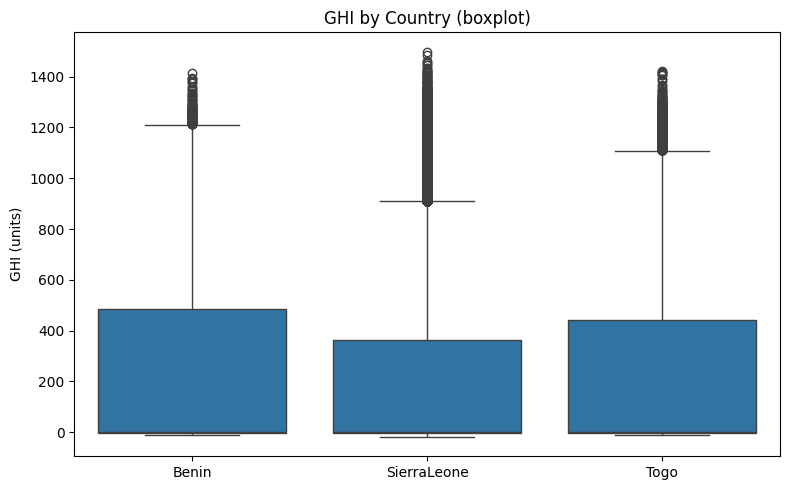

Saved: boxplot_dni_by_country.png


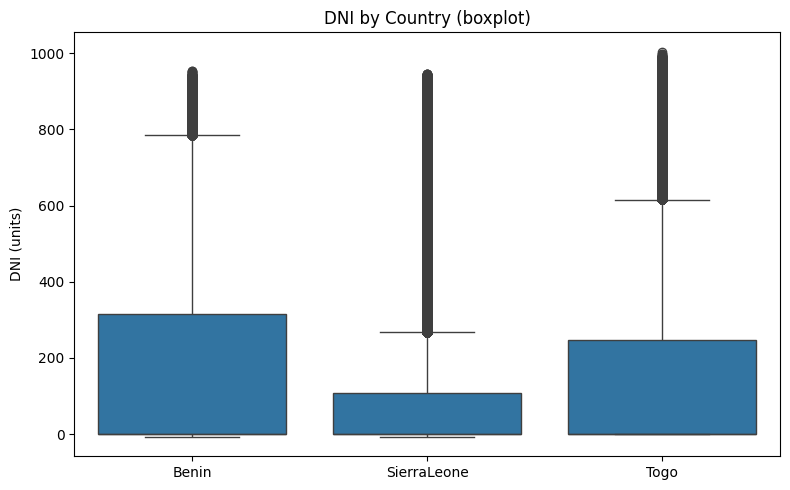

Saved: boxplot_dhi_by_country.png


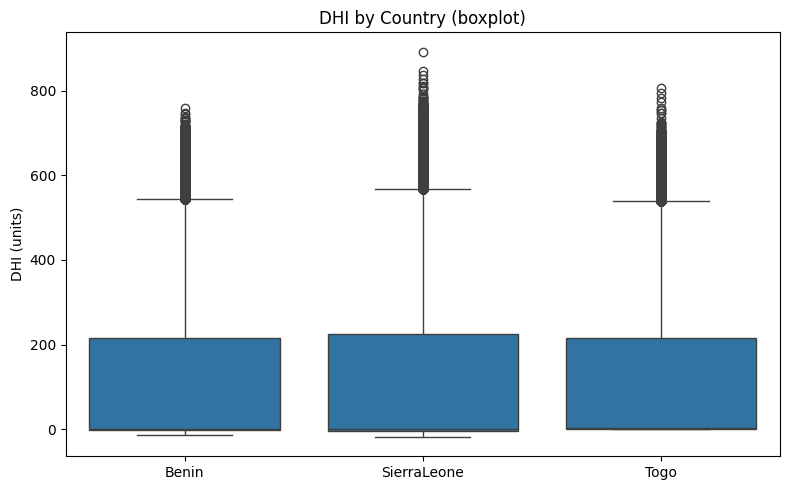

In [39]:

metrics = ['GHI','DNI','DHI']
for metric in metrics:
    plt.figure(figsize=(8,5))
    ax = sns.boxplot(data=df_metrics, x='country', y=metric)
    ax.set_title(f'{metric} by Country (boxplot)')
    ax.set_xlabel('')
    ax.set_ylabel(f'{metric} (units)')
    plt.tight_layout()
    out = f'boxplot_{metric.lower()}_by_country.png'
    plt.savefig(out, dpi=150)
    print("Saved:", out)
    plt.show()


In [40]:

summary = df_metrics.groupby('country')[['GHI','DNI','DHI']].agg(['mean','median','std'])
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()
display(summary)
summary.to_csv('summary_GHI_DNI_DHI_by_country.csv', index=False)
print("Saved: summary_GHI_DNI_DHI_by_country.csv")


,country,GHI_mean,GHI_median,GHI_std,DNI_mean,DNI_median,DNI_std,DHI_mean,DHI_median,DHI_std
0,Benin,240.559452,1.8,331.131327,167.187516,-0.1,261.710501,115.358961,1.6,158.691074
1,SierraLeone,201.957515,0.3,298.495150,116.376337,-0.1,218.652659,113.720571,-0.1,158.946032
2,Togo,230.555040,2.1,322.532347,151.258469,0.0,250.956962,116.444352,2.5,156.520714


Saved: summary_GHI_DNI_DHI_by_country.csv


In [41]:

groups = [df_metrics.loc[df_metrics['country']==c, 'GHI'].dropna() for c in summary['country']]
shapiro_results = {summary.loc[i,'country']: stats.shapiro(groups[i])
                   if len(groups[i])<=5000 else ('n>5000', None)
                   for i in range(len(groups))}

print("Shapiro results (group, stat, p-value) or 'n>5000':")
for k,v in shapiro_results.items():
    print(k, v)


levene_stat, levene_p = stats.levene(*groups, center='median')
print(f"Levene's test: stat={levene_stat:.3f}, p={levene_p:.3g}")
use_anova = (levene_p > 0.05)
print("Use ANOVA?" , use_anova)


Shapiro results (group, stat, p-value) or 'n>5000':
Benin ('n>5000', None)
SierraLeone ('n>5000', None)
Togo ('n>5000', None)
Levene's test: stat=1877.937, p=0
Use ANOVA? False


In [42]:

if use_anova:
    fstat, pval = stats.f_oneway(*groups)
    test_name = "One-way ANOVA"
else:
    fstat, pval = stats.kruskal(*groups)
    test_name = "Kruskal-Wallis"

print(f"{test_name} on GHI: stat = {fstat:.4f}, p-value = {pval:.3g}")
with open('ghi_stat_test.txt','w') as f:
    f.write(f"{test_name} on GHI: stat = {fstat:.6g}, p-value = {pval:.6g}\n")
print("Saved: ghi_stat_test.txt")


Kruskal-Wallis on GHI: stat = 4524.8835, p-value = 0
Saved: ghi_stat_test.txt


Saved: rank_mean_ghi_by_country.png


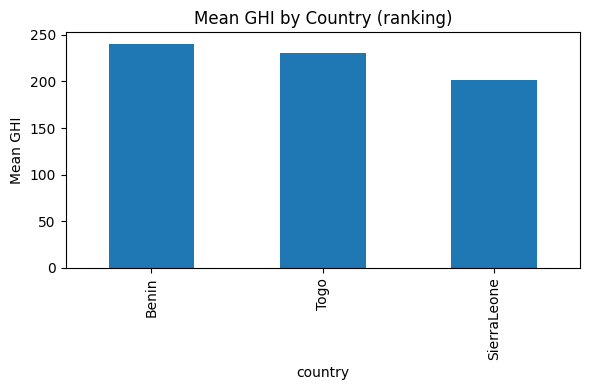

In [44]:
rank = df_metrics.groupby('country')['GHI'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
ax = rank.plot(kind='bar')
ax.set_ylabel('Mean GHI')
ax.set_title('Mean GHI by Country (ranking)')
plt.tight_layout()
out = 'rank_mean_ghi_by_country.png'
plt.savefig(out, dpi=150)
print("Saved:", out)
plt.show()
